In [1]:
import numpy as np
from numpy.linalg import norm
import scipy.sparse as sp
import matplotlib.pyplot as plt
import numba
from numba import cuda, float32, float64, int32
import time

Solving:

$$ \frac{\partial u}{\partial t}=\Delta u$$

$$ u(t,\ x,\ y)\in [0,\ ∞]\times[-1,\ 1]^2  $$

$$ u(t, 1, y) = u(t, x, -1) = u(t, x, 1) = 0;\ \ u(t, -1, y)=5$$

$$ t^*\approx 0.424011387033 \ \text{s.t. first occurence of } u(t^*, 0, 0)=1 $$

An immediate simplification exists, that due to the symmetry of the problem, we need only solve on the half-plane $[-1,1]\times[0,1]$, replacing the South Dirichlet boundary condition with a Neumann b.c. at $x=0$.

# CPU

## Time-discretisation and time-stepping

We will implement 2 time-stepping methods below, Forward-Euler and the Explicit RK4 (linear approximation to function $f$). These are both explicit, so it is worth discussing their CFL stability condition. First the schemes, though:

$$
(\frac{\partial u}{\partial t})_n \approx \frac{u(t_{n+1})-u(t_n)}{\Delta t} \qquad \text{(FE)}
$$

$\\ $

$$
k_1 = f(u_n) \\
k_2 = f(u_n + \frac12 \Delta t\ k_1) \\
k_3 = f(u_n + \frac12 \Delta t\ k_2) \\
k_4 = f(u_n + \Delta t\ k_3) \\
u_{n+1} \approx u_n + \frac{\Delta t}6(k_1+2k_2+2k_3+k_4)\qquad (\text{RK4})
$$





In [2]:
def feuler_step(u, A, dt):
  return u + dt * (A @ u)

def rk4_explicit_step(u, A, dt):
  k1 = A @ u
  k2 = A @ (u + 0.5 * dt * k1)
  k3 = A @ (u + 0.5 * dt * k2)
  k4 = A @ (u + dt * k3)

  return u + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

And below, one implicit scheme (Backward Euler):

$$
(\frac{\partial u}{\partial t})_{n+1}\approx\frac{u(t_{n+1})-u(t_n)}{\Delta t}
$$



In [3]:
def beuler_step(u, A, dt, solver=None, M=None):
  """
  Initliasie with solver=None, M=None;
  Loop like: u, solver, M = beuler(u, A, dt, solver, M)
  """
  if solver is None:
    if M is None:
      I = sp.eye(u.shape[0]).tocsr()
      M = I - dt * A
    solver = sp.linalg.factorized(M)

  u_new = solver(u)
  return u_new, solver, M

In [4]:
def feuler_halfplane_custom(N, dt=1e-5, u_target=1.0, Tmax=1.0):
  A, Nx, Ny = build_halfsolver_csr_njit(N)

  # Initialise u
  u = np.zeros((Ny, Nx))
  u[:, 0] = 5.0
  u[:, -1] = 0.0
  u[-1, :] = 0.0

  # Flatten into 1D-array for processing
  u = u.flatten()

  NxNy = Nx*Ny
  tally = 0

  while u[Nx // 2] < u_target:
    u = feuler_step(u, A, dt)
    tally += 1

    # Enforce boundaries without reshaping
    u[0::Nx] = 5.0
    u[Nx-1::Nx] = 0.0
    u[NxNy-Nx::NxNy] = 0.0

    if (tally * dt) > Tmax: print(f"Reached Tmax without convergence."); break

  return (tally*dt), u.reshape((Ny, Nx)), Nx, Ny



def rk4_halfplane_custom(N, dt=1e-5, u_target=1.0, Tmax=1.0):
  A, Nx, Ny = build_halfsolver_csr_njit(N)

  # Initialise u
  u = np.zeros((Ny, Nx))
  u[:, 0] = 5.0
  u[:, -1] = 0.0
  u[-1, :] = 0.0

  # Flatten into 1D-array for processing
  u = u.flatten()

  NxNy = Nx*Ny
  tally = 0
  while u[Nx // 2] < u_target:
    u = rk4_explicit_step(u, A, dt)
    tally += 1

    # Enforce boundaries without reshaping
    u[0::Nx] = 5.0
    u[Nx-1::Nx] = 0.0
    u[NxNy-Nx::NxNy] = 0.0

    if (tally * dt) > Tmax: print(f"Reached Tmax without convergence."); break

  return (tally*dt), u.reshape((Ny, Nx)), Nx, Ny




def beuler_halfplane_custom(N, dt=1e-5, u_target=1.0, Tmax=1.0):
  A, Nx, Ny = build_halfsolver_csr_njit(N)

  # Initialise u
  u = np.zeros((Ny, Nx))
  u[:, 0] = 5.0
  u[:, -1] = 0.0
  u[-1, :] = 0.0

  # Flatten into 1D-array for processing
  u = u.flatten()

  NxNy = Nx*Ny
  solver = None
  M = None
  tally = 0

  while u[Nx//2] < u_target:
    u, solver, M = beuler_step(u, A, dt, solver, M)
    tally += 1

    # Enforce boundaries without reshaping
    u[0::Nx] = 5.0
    u[Nx-1::Nx] = 0.0
    u[NxNy-Nx::NxNy] = 0.0

    if (tally * dt) > Tmax: print(f"Reached Tmax without convergence."); break

  return (tally*dt), u.reshape((Ny, Nx)), Nx, Ny

## Laplacian

We discetise u spatially in $x,\ y$ as $u_{i,\ j}=u(ih,\ jh)$, where h will be how fine our spatial grid is. Then $u$ is a matrix of size $(N+1,\ \frac N2+1)$, where $N=\frac1h$ (and we restrict N to be even so that we have exactly a node over $(x,y)=(0,0)$ to avoid needless interpolation).

We then flatten the matrix $u_{i,\ j}$ into a vector $\vec u=
\begin{pmatrix}
u_{00}\\
u_{01}\\
...\\
u_{0\frac N2}\\
u_{10}\\
...\\
u_{1\frac N2}\\
...\\
u_{N\frac N2}
\end{pmatrix}$ *(row/column-major order irrelevant)

We discretise $\Delta u$ accodring to the standard 5-point Laplacian stencil ($L$):

$$ L \approx\frac1{h^2}
\begin{bmatrix}
&1&\\
1 & \boxed{-4} & 1 \\
&1&
\end{bmatrix}$$

and for each of the North, East, West boundaries, we have $\frac{\partial u}{\partial t} = 0$, since they are Dirichlet, whereas for the South boundary, we apply a ghost-point to force the boundary to have zero flux.

That is, $L_N \approx \frac1{h^2}
\begin{bmatrix}
&2&\\
1&\boxed{-4}&1\\
\\
\end{bmatrix}$


Our solver will NOT necessarily use $h_x = h_y$, so we generalise the above concept directionally;

$$ L \approx\frac1{h_x^2}
\begin{bmatrix}
\\
1 & \boxed{-4} & 1 \\
\\
\end{bmatrix}
+ \frac1{h_y^2}
\begin{bmatrix}
&1&\\
 & \boxed{-4} &  \\
&1&
\end{bmatrix}$$
for a non-Neumann point.

---

For example, when $N = 5\ (N_x=5,\ N_y=3\implies\text{ matrix is }15\times15)$:

\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
4 & -16 & 4 & 0 & 0 & 0 & 8 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 4 & -16 & 4 & 0 & 0 & 0 & 8 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 4 & -16 & 4 & 0 & 0 & 0 & 8 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 4 & 0 & 0 & 0 & 4 & -16 & 4 & 0 & 0 & 0 & 4 & 0 & 0 & 0 \\
0 & 0 & 4 & 0 & 0 & 0 & 4 & -16 & 4 & 0 & 0 & 0 & 4 & 0 & 0 \\
0 & 0 & 0 & 4 & 0 & 0 & 0 & 4 & -16 & 4 & 0 & 0 & 0 & 4 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}


Although our solver will actually ignore Dirichlet boundaries in the matrix, and enforce them outside of the matrix multiplication loop, so all the $1$s in the diagonal will be 0 in our matrix builder below.

We see a clear block-matrix structure. Indeed, the first block-row has a Neumann(ghost-point)-type Laplace-like structure, and the last row-block is precisely the identity matrix in the last block. Any block-rows in-between will have a 5-point Laplace-like structure.

The block size is determined by $N$ - that is, the grid with which $u_{i,\ j}$ has been discretised. In particular, we require $N$ to be odd to allow us to easily abuse the symmetry in the problem (otherwise, we would have to do some interpolation shenanigans which is not fun, so we will just force the user into an odd-$N$ discretisation).

In [5]:
def build_halfsolver_csr(N, Lx=2.0, Ly=1.0):
  # Enforce odd N
  if (N&1==0): print(f"Run with: {N+1}"); N+=1

  Nx = N
  Ny = (N+1) // 2
  #hx = Lx / (Nx-1)
  #hy = Ly / (Ny-1)
  kx = ((Nx-1)/Lx)**2 # = 1/hx**2
  ky = ((Ny-1)/Ly)**2 # = 1/hy**2

  # At most 5 entries per row are NZ
  rows = np.empty(5*Nx*Ny, dtype=np.int32)
  cols = np.empty(5*Nx*Ny, dtype=np.int32)
  data = np.empty(5*Nx*Ny, dtype=np.float64)
  tally = 0

  for j in range(Ny):
    for i in range(Nx):
      idx = j * Nx + i

      # If Dirichlet, skip (i.e. zero-entry)
      if i==0 or i==Nx-1 or j==Ny-1: continue

      # All Laplace stencil members exist on a single row per operation
      rows[tally : tally+5] = idx

      # Central entry
      cols[tally] = idx
      data[tally] = -2*(kx+ky)
      tally += 1

      # West Neighbour (Wnb)
      cols[tally] = idx - 1
      data[tally] = kx
      tally += 1

      # Enb
      cols[tally] = idx + 1
      data[tally] = kx
      tally += 1

      # Nnb (Neumann)
      cols[tally] = idx + Nx
      data[tally] = 2*ky if j==0 else ky
      tally += 1

      # Snb (only if not Neumann)
      if j > 0:
        cols[tally] = idx - Nx
        data[tally] = ky
        tally += 1

  A = sp.csr_matrix((data[:tally], (rows[:tally], cols[:tally])),
                    shape=(Nx*Ny, Nx*Ny))

  return A, Nx, Ny



@numba.njit
def fill_halfsolver_csr_njit(N, Lx=2.0, Ly=1.0):
  # Enforce odd N
  if (N&1==0): print(f"Run with: {N+1}"); N+=1

  Nx = N
  Ny = (N+1) // 2
  hx = Lx / (Nx-1)
  hy = Ly / (Ny-1)
  kx = ((Nx-1)/Lx)**2
  ky = ((Ny-1)/Ly)**2

  # At most 5 entries per row are NZ
  rows = np.empty(5*Nx*Ny, dtype=np.int32)
  cols = np.empty(5*Nx*Ny, dtype=np.int32)
  data = np.empty(5*Nx*Ny, dtype=np.float64)
  tally = 0

  for j in range(Ny):
    for i in range(Nx):
      idx = j * Nx + i

      # If Dirichlet, skip (i.e. zero-entry)
      if i==0 or i==Nx-1 or j==Ny-1: continue

      # All Laplace stencil members exist on a single row per operation
      rows[tally : tally+5] = idx

      # Central entry
      cols[tally] = idx
      data[tally] = -2*(kx+ky)
      tally += 1

      # West Neighbour (Wnb)
      cols[tally] = idx - 1
      data[tally] = kx
      tally += 1

      # Enb
      cols[tally] = idx + 1
      data[tally] = kx
      tally += 1

      # Nnb (Neumann)
      cols[tally] = idx + Nx
      data[tally] = 2*ky if j==0 else ky
      tally += 1

      # Snb (only if not Neumann)
      if j > 0:
        cols[tally] = idx - Nx
        data[tally] = ky
        tally += 1

  return data[:tally], rows[:tally], cols[:tally], Nx, Ny

def build_halfsolver_csr_njit(N):
  data, rows, cols, Nx, Ny = fill_halfsolver_csr_njit(N)
  A = sp.csr_matrix((data, (rows, cols)), shape=(Nx*Ny, Nx*Ny))
  return A, Nx, Ny

Let us verify which of these is actually faster!

In [11]:
Ns = [11, 25, 51, 101, 151, 301, 501, 1001, 2001]

times = []
times_njit = []

for n in Ns:
  print(n)

  t0 = time.perf_counter()
  _ = build_halfsolver_csr(n)
  t = time.perf_counter() - t0
  times.append(t)

  t0 = time.perf_counter()
  _ = build_halfsolver_csr_njit(n)
  t = time.perf_counter() - t0
  times_njit.append(t)

11
25
51
101
151
301
501
1001
2001


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3274348921.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Compile time for matrix, size $\sim N^2$")


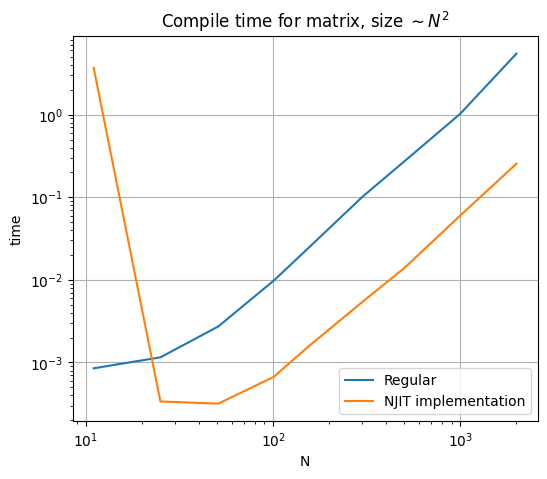

In [12]:
plt.figure(figsize=(6, 5))
plt.loglog(Ns, times, label="Regular")
plt.loglog(Ns, times_njit, label="NJIT implementation")
plt.legend()
plt.grid()
plt.xlabel("N")
plt.ylabel("time")
plt.title("Compile time for matrix, size $\sim N^2$")
plt.show()

As we can see, the NJIT implementation is quicker, which was to be expected, which is why we used that in the integrators we defined before (of course, ignoring the ~2s of overhead we have for the first operation).

Let us now consider each of our forward, backward Euler and 4th order Runge-Kutta methods;




In [13]:
t0 = time.perf_counter()
t_target_fe,  u_fe,   Nx_fe,  Ny_fe   = feuler_halfplane_custom(201, dt=1e-5)
t_fe = time.perf_counter() - t0

t0 = time.perf_counter()
t_target_rk4, u_rk4,  Nx_rk4, Ny_rk4  = rk4_halfplane_custom(201, dt=1e-5)
t_rk4 = time.perf_counter() - t0

t0 = time.perf_counter()
t_target_be,  u_be,   Nx_be,  Ny_be   = beuler_halfplane_custom(201, dt=1e-5)
t_be = time.perf_counter() - t0

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Forward Euler $t^*=$ 0.42401 took 8.01s.
Explicit RK5 $t^*=$ 0.42402 took 33.51s.
Backward Euler $t^*=$ 0.42403 took 2m, 20.38s.


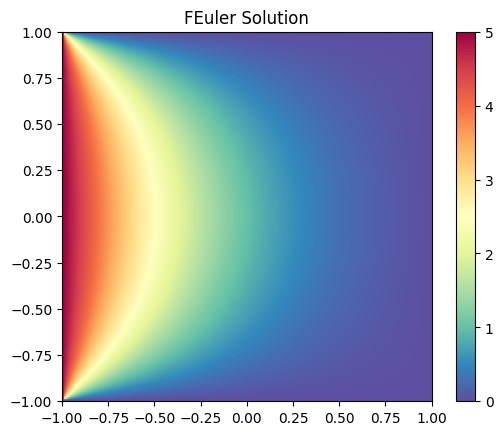

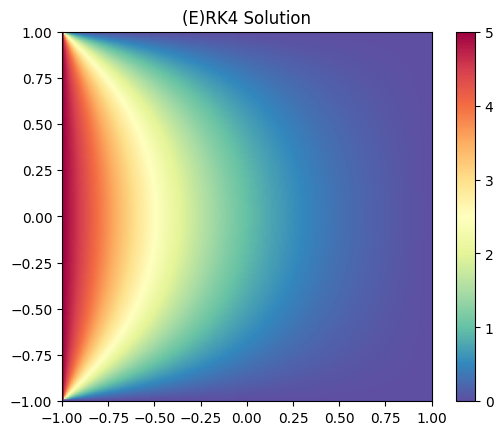

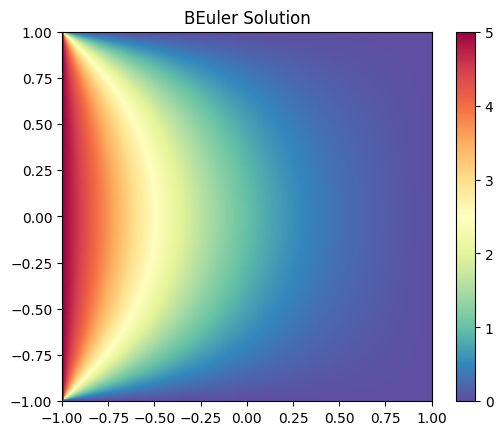

In [14]:
print(f"Forward Euler $t^*=$ {t_target_fe:.5f} took {t_fe:.2f}s.")
print(f"Explicit RK5 $t^*=$ {t_target_rk4:.5f} took {t_rk4:.2f}s.")
print(f"Backward Euler $t^*=$ {t_target_be:.5f} took {t_be//60:.0f}m, {t_be%60:.2f}s.")

u = u_fe.reshape((Ny_fe, Nx_fe))
u_full = np.vstack([u[:0:-1, :], u]) # Reconstruct full solution
plt.imshow(u_full, origin="lower", extent=[-1, 1, -1, 1], cmap="Spectral_r")
plt.colorbar()
plt.title("FEuler Solution")
plt.show()

u = u_rk4.reshape((Ny_rk4, Nx_rk4))
u_full = np.vstack([u[:0:-1, :], u]) # Reconstruct full solution
plt.imshow(u_full, origin="lower", extent=[-1, 1, -1, 1], cmap="Spectral_r")
plt.colorbar()
plt.title("(E)RK4 Solution")
plt.show()

u = u_be.reshape((Ny_be, Nx_be))
u_full = np.vstack([u[:0:-1, :], u]) # Reconstruct full solution
plt.imshow(u_full, origin="lower", extent=[-1, 1, -1, 1], cmap="Spectral_r")
plt.colorbar()
plt.title("BEuler Solution")
plt.show()

We see a reasonable solution is plotted by all of our solvers, and a fairly good approximation to $t^*$ is given by all of our solvers. We can also see that the forward Euler method is by far the quickest (and simplest), so we will proceed with that method in calculating the best $t^*$ approximation we can.

(Also, of course we have used CSR format to efficiently store the matrix - this is clear enough, but worth mentioning, I suppose.)

## Stability (CFL condition)

It is possible (and not difficult) to arrive at an analytical value for which the following, $C$, which helps us determine for which values (under what conditions) an explicit method is stable (implicit methods are unconditionally stable):
$$
C := \frac{\Delta t}{\Delta x\Delta y} \approx \frac{\Delta t}{\frac{1}{N_x}\frac{1}{N_y}} = N_xN_y\Delta t
$$
There are many equivalent definitions for the Courant-Friedrich-Lewy number, scaled by a constant. The important part is that under a certain value, we have a stable solution, and above it, we have an unstable solution.

The analytical constant is sometimes also not entirely representative of our problem's specific stability, as it is a worst-case bound. With that in mind, we will simply stick with experimental data to analyse stability.




In [15]:
def test_stability(A, NxNy, stepper, dt, n_steps):
  u = np.random.randn(NxNy)

  for _ in range(n_steps):
    u = stepper(u, A, dt)
    if not np.isfinite(u).all(): return False
    if norm(u) > 1e8: return False
  return True

In [16]:
Ns = [11, 25, 51, 101, 251]
dts = [1e-3, 1e-4, 5e-5]
nsteps_arr = [int(0.5/dt) for dt in dts]

stableC_fe, unstableC_fe = [], []
stableC_rk4, unstableC_rk4 = [], []

for N in Ns:
  A, Nx, Ny = build_halfsolver_csr(N)
  for i in range(len(dts)):
    dt = dts[i]
    nsteps = nsteps_arr[i]
    NxNy = Nx*Ny
    test_fe = test_stability(A, NxNy, feuler_step, dt, nsteps)
    test_rk4 = test_stability(A, NxNy, rk4_explicit_step, dt, nsteps)
    print(f"(FE, RK4) stable?: {test_fe, test_rk4} for (N, dt)=({NxNy}, {dt})")
    C = dt*NxNy
    if test_fe: stableC_fe.append(C)
    else: unstableC_fe.append(C)
    if test_rk4: stableC_rk4.append(C)
    else: unstableC_rk4.append(C)

stableC_fe.sort(), unstableC_fe.sort()
stableC_rk4.sort(), unstableC_rk4.sort()

print(f"Stability for Forward Euler is between {max(stableC_fe)}, and {min(unstableC_fe)}.")
print(f"Stability for Explicit RK4 is between {max(stableC_rk4)}, and {min(unstableC_rk4)}.")

(FE, RK4) stable?: (True, True) for (N, dt)=(66, 0.001)
(FE, RK4) stable?: (True, True) for (N, dt)=(66, 0.0001)
(FE, RK4) stable?: (True, True) for (N, dt)=(66, 5e-05)
(FE, RK4) stable?: (True, True) for (N, dt)=(325, 0.001)
(FE, RK4) stable?: (True, True) for (N, dt)=(325, 0.0001)
(FE, RK4) stable?: (True, True) for (N, dt)=(325, 5e-05)
(FE, RK4) stable?: (False, False) for (N, dt)=(1326, 0.001)
(FE, RK4) stable?: (True, True) for (N, dt)=(1326, 0.0001)
(FE, RK4) stable?: (True, True) for (N, dt)=(1326, 5e-05)
(FE, RK4) stable?: (False, False) for (N, dt)=(5151, 0.001)
(FE, RK4) stable?: (True, True) for (N, dt)=(5151, 0.0001)
(FE, RK4) stable?: (True, True) for (N, dt)=(5151, 5e-05)
(FE, RK4) stable?: (False, False) for (N, dt)=(31626, 0.001)
(FE, RK4) stable?: (False, False) for (N, dt)=(31626, 0.0001)
(FE, RK4) stable?: (False, False) for (N, dt)=(31626, 5e-05)
Stability for Forward Euler is between 0.5151, and 1.326.
Stability for Explicit RK4 is between 0.5151, and 1.326.


The above setup was not good for testing stability of the process with respect to CFL number, $C$, however it gives us some data;

As we can see, the CFL number is somewhere between $C=0.5151$, and $C=1.326$. We can try to estimate it to a higher precision;

In [17]:
Cs = [0.55, 0.60, 0.65, 0.70, 0.75, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3]
A, Nx, Ny = build_halfsolver_csr(51)
NxNy = Nx*Ny

dts = [C/NxNy for C in Cs]
nsteps_arr = [int(0.5/dt) for dt in dts]

for i in range(len(Cs)):
  test_fe = test_stability(A, NxNy, feuler_step, dts[i], nsteps_arr[i])
  test_rk4 = test_stability(A, NxNy, rk4_explicit_step, dts[i], nsteps_arr[i])

  if test_fe: stableC_fe.append(Cs[i])
  else: unstableC_fe.append(Cs[i])

  if test_rk4: stableC_rk4.append(Cs[i])
  else: unstableC_rk4.append(Cs[i])

stableC_fe.sort(), unstableC_fe.sort()
stableC_rk4.sort(), unstableC_rk4.sort()

print(f"Stability for Forward Euler is between {max(stableC_fe)}, and {min(unstableC_fe)}.")
print(f"Stability for Explicit RK4 is between {max(stableC_rk4)}, and {min(unstableC_rk4)}.")

Stability for Forward Euler is between 0.5151, and 0.55.
Stability for Explicit RK4 is between 0.7, and 0.75.


And one more, finer step:

In [18]:
Cs_fe = [.515, .52, .525, .53, .535, .54, .545, .55]
Cs_rk4 = [.7, .705, .71, .715, .72, .725, .73, .735, .74, .745, .75]

A, Nx, Ny = build_halfsolver_csr(101)
NxNy = Nx*Ny

dts_fe = [C/NxNy for C in Cs_fe]
dts_rk4 = [C/NxNy for C in Cs_rk4]
nsteps_arr_fe = [int(0.5/dt) for dt in dts_fe]
nsteps_arr_rk4 = [int(0.5/dt) for dt in dts_rk4]

for i in range(len(Cs_fe)):
  test_fe = test_stability(A, NxNy, feuler_step, dts_fe[i], nsteps_arr_fe[i])
  if test_fe: stableC_fe.append(Cs_fe[i])
  else: unstableC_fe.append(Cs_fe[i])

for i in range(len(Cs_rk4)):
  test_rk4 = test_stability(A, NxNy, rk4_explicit_step, dts_rk4[i], nsteps_arr_rk4[i])
  if test_rk4: stableC_rk4.append(Cs_rk4[i])
  else: unstableC_rk4.append(Cs_rk4[i])

stableC_fe.sort(), unstableC_fe.sort()
stableC_rk4.sort(), unstableC_rk4.sort()

print(f"Stability for Forward Euler is between {max(stableC_fe)}, and {min(unstableC_fe)}")
print(f"Stability for Explicit RK4 is between {max(stableC_rk4)}, and {min(unstableC_rk4)}")

Stability for Forward Euler is between 0.5151, and 0.52
Stability for Explicit RK4 is between 0.715, and 0.72


This implementation works as a proof of concept, we can continue to increase our level of precision.




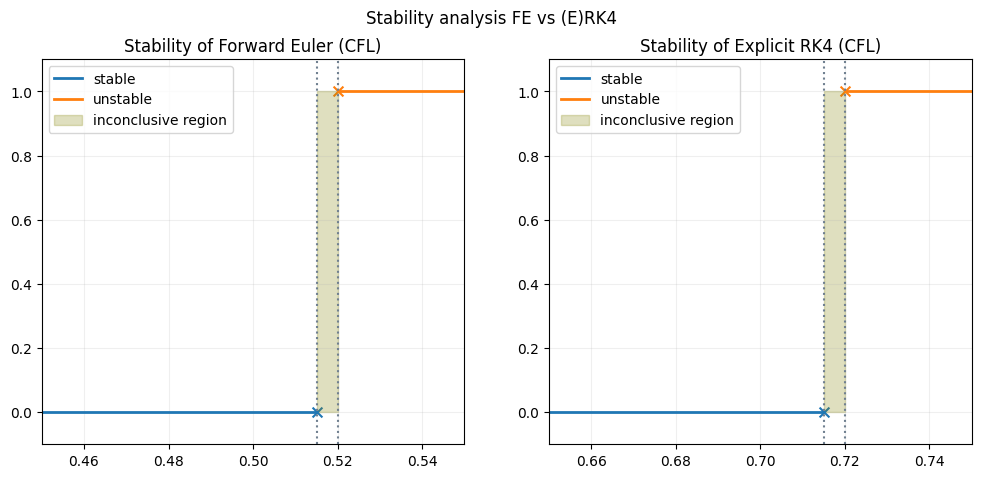

In [19]:
plt.figure(figsize=(12,5))
plt.suptitle("Stability analysis FE vs (E)RK4")

plt.subplot(1,2,1)
plt.plot(stableC_fe, [0 for _ in range(len(stableC_fe))], label="stable", lw=2.0)
plt.plot(unstableC_fe, [1 for _ in range(len(unstableC_fe))], label="unstable", lw=2.0)
plt.scatter([max(stableC_fe)], [0], marker="x", s=50)
plt.scatter([min(unstableC_fe)], [1], marker="x", s=50)
plt.xlim(0.45, 0.55)
plt.ylim((-0.1, 1.1))
plt.axvline(min(unstableC_fe), color="slategrey", linestyle=":")
plt.axvline(max(stableC_fe), color="slategrey", linestyle=":")
plt.fill_between((min(unstableC_fe), max(stableC_fe)), (1), color="olive", alpha=0.25, label="inconclusive region")
plt.legend()
plt.grid(alpha=0.2)
plt.title("Stability of Forward Euler (CFL)")

plt.subplot(1,2,2)
plt.plot(stableC_rk4, [0 for _ in range(len(stableC_rk4))], label="stable", lw=2.0)
plt.plot(unstableC_rk4, [1 for _ in range(len(unstableC_rk4))], label="unstable", lw=2.0)
plt.scatter([max(stableC_rk4)], [0], marker="x", s=50)
plt.scatter([min(unstableC_rk4)], [1], marker="x", s=50)
plt.xlim(0.65, 0.75)
plt.ylim((-0.1, 1.1))
plt.axvline(min(unstableC_rk4), color="slategrey", linestyle=":")
plt.axvline(max(stableC_rk4), color="slategrey", linestyle=":")
plt.fill_between((min(unstableC_rk4), max(stableC_rk4)), (1), color="olive", alpha=0.25, label="inconclusive region")
plt.legend()
plt.grid(alpha=0.2)
plt.title("Stability of Explicit RK4 (CFL)")

plt.show()

That's far cleaner. As we see, the inconclusive region can be shrunk by running more simulations in that region until the user's desired level of precision is reached. For us, this is good enough. Also, recall the arbitrary threshold we set in our tester function of:

"As long as the norm of the vector $u$ does not reach 1e8, then we consider the solution stable." This is of course, not a very rigorous or necessarily good threshold, but it is good to get a general idea of how our funciton behaves.




In [20]:
A, Nx, Ny = build_halfsolver_csr(51)

xgrid = np.linspace(0, 1.0, Nx)


# Stable example #
C_fe = 0.51
C_rk4 = 0.71

dt_fe = C_fe/(Nx*Ny)
dt_rk4 = C_rk4/(Nx*Ny)

_,  sol_fe_stable, _, _= feuler_halfplane_custom(51, dt=dt_fe)
_, sol_rk4_stable, _, _= rk4_halfplane_custom(51, dt=dt_rk4)


# Unstable example #
C_fe = 0.54
C_rk4 = 0.741518

dt_fe = C_fe/(Nx*Ny)
dt_rk4 = C_rk4/(Nx*Ny)

_,  sol_fe_unstable, _, _= feuler_halfplane_custom(51, dt=dt_fe)
_, sol_rk4_unstable, _, _= rk4_halfplane_custom(51, dt=dt_rk4)


# Only print x=0 for ease
sol_fe_stable    = sol_fe_stable[0, :]
sol_fe_unstable  = sol_fe_unstable[0, :]
sol_rk4_stable   = sol_rk4_stable[0, :]
sol_rk4_unstable = sol_rk4_unstable[0, :]

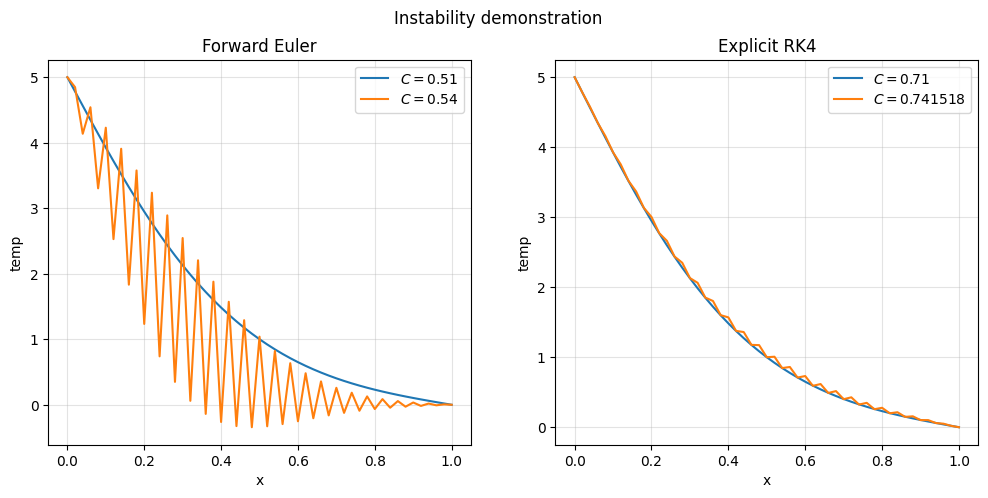

In [35]:
plt.figure(figsize=(12, 5))
plt.suptitle("Instability demonstration")

plt.subplot(1,2,1)
plt.plot(xgrid, sol_fe_stable, label="$C=0.51$")
plt.plot(xgrid, sol_fe_unstable, label=f"$C={C_fe}$")
plt.xlabel("x")
plt.ylabel("temp")
plt.legend()
plt.grid(alpha=0.35)
plt.title("Forward Euler")

plt.subplot(1,2,2)
plt.plot(xgrid, sol_rk4_stable, label="$C=0.71$")
plt.plot(xgrid, sol_rk4_unstable, label=f"$C={C_rk4}$")
plt.title("Explicit RK4")
plt.xlabel("x")
plt.ylabel("temp")
plt.legend()
plt.grid(alpha=0.35)

plt.show()

Note: I realise the RK4 unstable C is oddly specific, but there turns out to be a very fine line of a stable solution and catasrophic blow-up. The in-between is not as easy to find, compared to the forward Euler method.

Below, we also see that although the backward Euler method has no issues converging, even at ridiculous values of $C$, we still wish to keep it small for accuracy reasons.

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Reached Tmax without convergence.


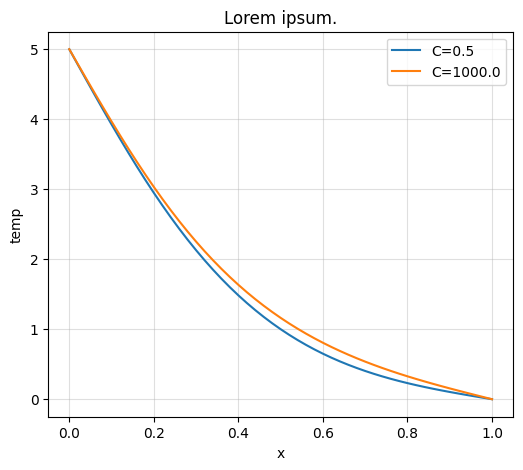

In [36]:
A, Nx, Ny = build_halfsolver_csr(51)

xgrid = np.linspace(0, 1.0, Nx)


# Stable example #
C_be_s = 0.50
dt_be_s = C_be_s/(Nx*Ny)
_,  sol_be_stable, _, _= beuler_halfplane_custom(51, dt=dt_be_s)

# Unstable example #
C_be_us = 1000.0
dt_be_us = C_be_us/(Nx*Ny)
_,  sol_be_unstable, _, _= beuler_halfplane_custom(51, dt=dt_be_us)


sol_be_stable = sol_be_stable[0, :]
sol_be_unstable = sol_be_unstable[0, :]

plt.figure(figsize=(6, 5))
plt.title("Lorem ipsum.")
plt.plot(xgrid, sol_be_stable, label=f"C={C_be_s}")
plt.plot(xgrid, sol_be_unstable, label=f"C={C_be_us}")
plt.legend()
plt.grid(alpha=0.4)
plt.xlabel("x")
plt.ylabel("temp")
plt.show()

# GPU

And now the fun part!

Since we are using a 5-point Laplace stencil, using shared memory will give us a good amount of speed-up. Let's start with the kernel.



In [23]:
TPBx = 16
TPBy = 16

SHDx = TPBx+2
SHDy = TPBy+2

In [24]:
@cuda.jit
def feuler_halfplane_kernel_custom(u_old, u_new, Nx, Ny, kx, ky, dt):
  """
  Shared Memory array indexed as (tx, ty)

 ` tx   0   1   2  ... bwx bwx bwx
ty                      -1      +1
      +---+---+---+---+---+---+---+
0     | C | T | T |...| T | T | C |
1     | L | M | M |...| M | M | R |
2     | L | M | M |...| M | M | R |
...   |    ...     ...     ...    |
bwy-1 | L | M | M |...| M | M | R |
bwy   | L | M | M |...| M | M | R |
bwy+1 | C | B | B |...| B | B | C |
      +---+---+---+---+---+---+---+

  Halo enries are all of C, T, B, L, R (Corner, Top, Bottom, Left, Right).
  """
  shared = cuda.shared.array((SHDy, SHDx), dtype=float64)

  tx = cuda.threadIdx.x
  ty = cuda.threadIdx.y
  bx = cuda.blockIdx.x
  by = cuda.blockIdx.y
  bwx = cuda.blockDim.x
  bwy = cuda.blockDim.y

  i = bx * bwx + tx # This is i, j = cuda.grid(2), but
  j = by * bwy + ty # we need tx, ty for shared memory

  li = tx+1 #
  lj = ty+1 # local array indexing

  idx = j * Nx + i

  # Thread guard
  if i>=Nx or j>=Ny: return

  #~ Load central entries ~#
  shared[lj, li] = u_old[idx]

  #~ Left/Right halo ~#
  # Below we force the edge threads to do extra operations, so this isn't
  # really worth it since each halo element is only ever used by a single
  # thread, but it enables us to handle edge threads in a uniform way with
  # all other threads without checking if they are boundary threads indeed
  # (which would also introduce more operations), so this trade-off is worth it.

  # Below, we request i>0 and j<Ny; this is to ensure
  # we don't read OOB/illegal memory.
  if tx==0 and i>0:
    shared[lj, 0] = u_old[idx-1]
  if tx==bwx-1 and i<Nx-1:
    shared[lj, bwx+1] = u_old[idx+1]

  #~ Top/Bottom halo ~#
  if ty==0 and j>0:
    shared[0, li] = u_old[idx-Nx]
  if ty==bwy-1 and j<Ny-1:
    shared[bwy+1, li] = u_old[idx+Nx]

  # Corner loads not worth it.

  # Required syncthreads jail, else later we read illegal memory.
  cuda.syncthreads()

  # Dirichlet:
  if i==0:
    u_new[idx] = 5.0
    return

  if i==Nx-1 or j==Ny-1:
    u_new[idx] = 0.0
    return

  u_c = shared[lj, li]
  u_w = shared[lj, li-1]
  u_e = shared[lj, li+1]
  u_n = shared[lj+1, li]

  # Neumann:
  if j==0:
    u_s = u_n
  else:
    u_s = shared[lj-1, li]

  lap = (
      kx * (u_w - 2.0 * u_c + u_e) +
      ky * (u_n - 2.0 * u_c + u_s))

  u_new[idx] = u_c + dt * lap

Something that I personally found confusing in shared arrays; I originally thought of threads as "living inside" the shared array... I pictured them as living in the shared array indexes [(1), (1)] -> [(bwx-1), (bwy-1)], which is obviously not the case.

We simply have that every block allocates a piece of shared memory (size [TX+2, TY+2]), which each thread can access, and have chosen a scheme in which the local indexes differ by 1 in each dimension. That is, loc_i = tx+1 and loc_j = ty+1.

Another non-ridiculous scheme for storing our shared memory could be;




In [25]:
"""
  Shared Memory array indexed as (tx, ty)

 ` tx   0   1  ... bwx bwx bwx bwx
ty                  -2  -1      +1
      +---+---+---+---+---+---+---+
0     | M | M |...| M | M | L | R |
1     | M | M |...| M | M | L | R |
...   |  ...   ...   ...     ...  |
bwy-2 | M | M |...| M | M | L | R |
bwy-1 | M | M |...| M | M | L | R |
bwy   | T | T |...| T | T | C | C |
bwy+1 | B | B |...| B | B | C | C |
      +---+---+---+---+---+---+---+

  Halo enries are all of C, T, B, L, R (Corner, Top, Bottom, Left, Right).

  In this case, we store all M (Middle) entries with local index = thread index,
  but we store halos on the right edges of the allocated shared memory array.
  It's a fine scheme, and works well, just as the one we used.
"""

"\n  Shared Memory array indexed as (tx, ty)\n\n ` tx   0   1  ... bwx bwx bwx bwx\nty                  -2  -1      +1\n      +---+---+---+---+---+---+---+\n0     | M | M |...| M | M | L | R |\n1     | M | M |...| M | M | L | R |\n...   |  ...   ...   ...     ...  |\nbwy-2 | M | M |...| M | M | L | R |\nbwy-1 | M | M |...| M | M | L | R |\nbwy   | T | T |...| T | T | C | C |\nbwy+1 | B | B |...| B | B | C | C |\n      +---+---+---+---+---+---+---+\n\n  Halo enries are all of C, T, B, L, R (Corner, Top, Bottom, Left, Right).\n\n  In this case, we store all M (Middle) entries with local index = thread index,\n  but we store halos on the right edges of the allocated shared memory array.\n  It's a fine scheme, and works well, just as the one we used.\n"

And now, let us create our launcher function;

In [26]:
def gpu_feuler_halfplane_custom(N, dt, u_target=1.0, Tmax=1.0, Lx=2.0, Ly=1.0):
  if (N&1==0): print(f"Run with {N+1}."); N+=1

  h_Nx = N
  h_Ny = (N+1)//2
  h_kx = ((h_Nx-1)/Lx)**2
  h_ky = ((h_Ny-1)/Ly)**2

  h_u = np.zeros((h_Ny, h_Nx), dtype=np.float64)
  h_u[:, 0] = 5.0

  d_u_old = cuda.to_device(h_u.flatten())
  d_u_new = cuda.device_array_like(d_u_old)

  threads = ((TPBx), (TPBy))
  blocks = (((h_Nx + TPBx - 1) // TPBx),
            ((h_Ny + TPBy - 1) // TPBy))

  h_mid_idx = h_Nx // 2
  h_maxiter = int32(Tmax // dt) + 1
  h_tally = 0

  while h_tally < h_maxiter:
    feuler_halfplane_kernel_custom[blocks, threads](d_u_old, d_u_new, h_Nx, h_Ny, h_kx, h_ky, dt)
    h_tally += 1

    # Stopping criterion (copy only 1 value to host):
    h_u_mid = d_u_new[h_mid_idx:h_mid_idx+1].copy_to_host()[0]
    if h_u_mid >= u_target: break

    # Ping-pong buffer
    d_u_old, d_u_new = d_u_new, d_u_old

  if not (h_tally < h_maxiter): print("Tmax reached without convergence")
  return (h_tally*dt), d_u_old.copy_to_host().reshape(h_Ny, h_Nx), h_Nx, h_Ny

In [27]:
t, u, Nx, Ny = gpu_feuler_halfplane_custom(201, 1e-5)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 91 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


0.42401000000000005


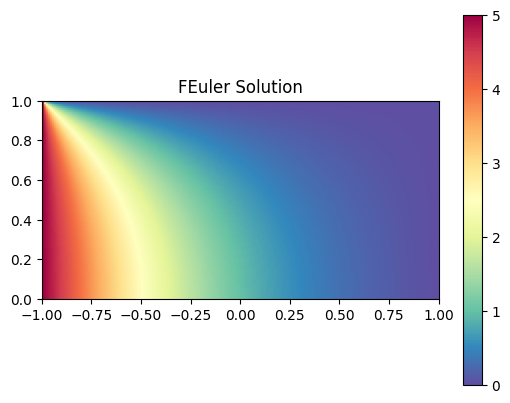

In [28]:
print(t)
plt.imshow(u, origin="lower", extent=[-1, 1, 0, 1], cmap="Spectral_r")
plt.colorbar()
plt.title("FEuler Solution")
plt.show()

Great, our solution looks fine, so let us start pushing this scheme to give us higher precision.

In [31]:
Ns = [51, 101, 251, 501, 1001]
# Nxs = [N for N in Ns]
# Nys = [(N+1)//2 for N in Ns]

# Choose dt such that C is within stable region!
# Say, C=0.5 or 0.45 should more than suffice
# dt = C/NxNy = C / (N*(N+1)/2) = 2C/(N*(N+1))
dts = [0.9/(N*(N+1)) for N in Ns]

t_ast_arr = []
times = []
t_ast = 0.424011387033

for i in range(len(Ns)):
  print(Ns[i])
  t0 = time.perf_counter()
  t_ast_est, _, _, _ = gpu_feuler_halfplane_custom(Ns[i], dts[i])
  t = time.perf_counter() - t0
  times.append(t)
  t_ast_arr.append(t_ast_est)

errors = [np.abs(t_ast-t_ast_arr[i]) for i in range(len(Ns))]

51
101
251
501
1001


Take notice of our choice of $C$. If it is too large, our integration scheme will become unstable, as previously presented. However, if our value is too low, then we simply waste GPU time with unnecessarily small time-steps.


We need to strike a balance between solution stability, accuracy and computational complexity.




In [91]:
scalar = errors[0]/(Ns[0]**(-2))
ref_errors = [scalar * n**(-2) for n in Ns]

scalar = times[0]/(Ns[0]**2)
ref_times = [scalar * n**2 for n in Ns]

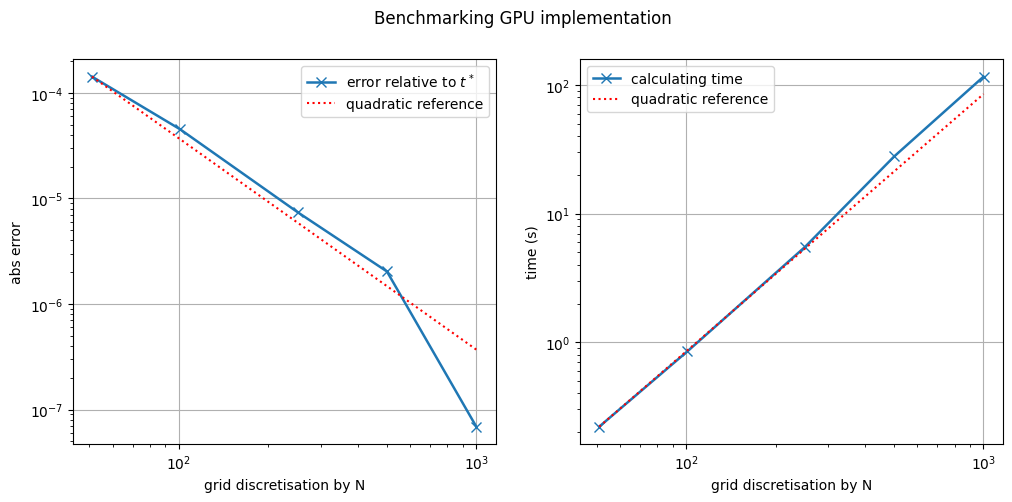

In [93]:
plt.figure(figsize=(12,5))
plt.suptitle("Benchmarking GPU implementation")

plt.subplot(1,2,1)
plt.loglog(Ns, errors, "-x", lw=1.8, ms="7", label="error relative to $t^*$")
plt.loglog(Ns, ref_errors, ":", color="r", label="quadratic reference")
plt.xlabel("grid discretisation by N")
plt.ylabel("abs error")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.loglog(Ns, times, "-x", lw=1.8, ms="7", label="calculating time")
plt.loglog(Ns, ref_times, ":", color="r", label="quadratic reference")
plt.xlabel("grid discretisation by N")
plt.ylabel("time (s)")
plt.legend()
plt.grid()
plt.show()

We see our error significantly decrease.

In [95]:
print(f"Given value for $t^*$: {t_ast}.")
print(f"Estimated value for $t^*$: {t_ast_est}.")

Given value for $t^*$: 0.424011387033.
Estimated value for $t^*$: 0.42401131802329406.


We see agreement to 6 decimal points (error $\approx$ 1e-7). This is decent.

Let's try a finer grid for fun;

In [96]:
N = 2001
dt = 0.9/(N*(N+1))

t0 = time.perf_counter()
t_ast_est, _, _, _ = gpu_feuler_halfplane_custom(N, dt)
t = time.perf_counter() - t0

times.append(t)
errors.append(np.abs(t_ast - t_ast_est))

In [104]:
Ns = [51, 101, 251, 501, 1001, 2001]
dts = [0.9/(N*(N+1)) for N in Ns]

scalar = errors[0]/(Ns[0]**(-2))
ref_errors = [scalar * n**(-2) for n in Ns]

scalar = times[0]/(Ns[0]**2)
ref_times = [scalar * n**2 for n in Ns]

Given value for $t^*$: 0.424011387033.
Estimated value for $t^*$: 0.42401122116264545.


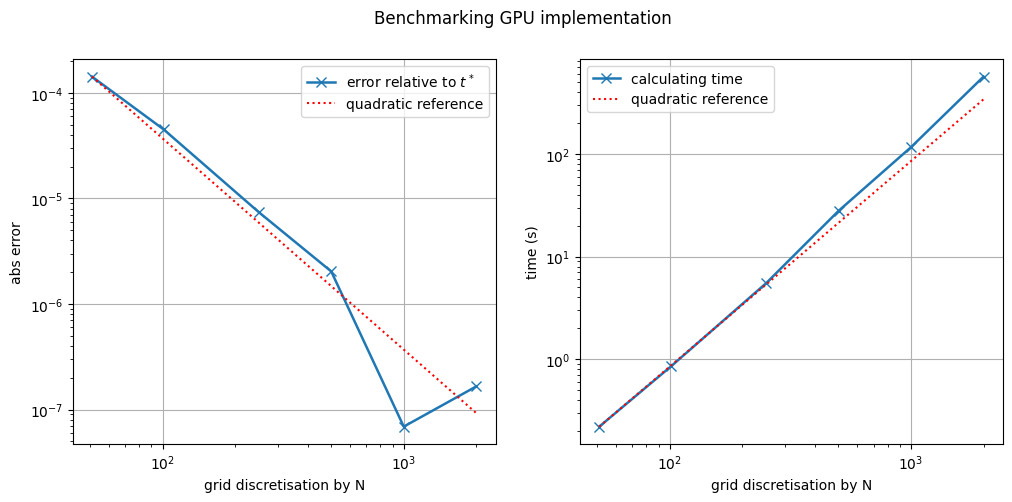

In [106]:
print(f"Given value for $t^*$: {t_ast}.")
print(f"Estimated value for $t^*$: {t_ast_est}.")

plt.figure(figsize=(12,5))
plt.suptitle("Benchmarking GPU implementation")

plt.subplot(1,2,1)
plt.loglog(Ns, errors, "-x", lw=1.8, ms="7", label="error relative to $t^*$")
plt.loglog(Ns, ref_errors, ":", color="r", label="quadratic reference")
plt.xlabel("grid discretisation by N")
plt.ylabel("abs error")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.loglog(Ns, times, "-x", lw=1.8, ms="7", label="calculating time")
plt.loglog(Ns, ref_times, ":", color="r", label="quadratic reference")
plt.xlabel("grid discretisation by N")
plt.ylabel("time (s)")
plt.legend()
plt.grid()
plt.show()

Something interesting happens here. Our error actually increases! This is likely because our $C$-value is too high. If we decrease our $C=0.45$ to something smaller, say $0.3$, then we would likely go back to seeing a decrease in error again. However, that previous simulation arleady took 9 minutes so I am hesitant to run it again with an even smaller time-step, so this will have to do.

Conclusion: My hypothesis is that our $C$ value got too large ($dt$ was not small enough), and our errors began to grow. It is likely that for $N=1001$, we accidentally found a slightly more optimal $dt$, which is why we see such a relatively large accuracy improvement over the previous iteration ($N=501$).

It is <ins>NOT</ins> due to double-precisoin floating point error. A 53-bit mantissa allows us almost 1e-16 accuracy.

